In [ ]:
import pandas as pd
# Đọc file 2020
df2020 = pd.read_csv('/content/aqi_airqualitydata_2020_en (1).csv')
# Đọc file 2021
df2021 = pd.read_csv('/content/historical_air_quality_2021_en.csv')


In [ ]:
#lọc dữ liệu 2020
df_pm25_2020 = df2020[df2020['Specie'] == 'pm25'][['Date', 'City', 'median']]
df_pm25_2020.rename(columns={'median': 'PM2.5'}, inplace=True)
df_pm25_2020['Date'] = pd.to_datetime(df_pm25_2020['Date']).dt.date


/tmp/ipython-input-3-842610940.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_pm25_2020['Date'] = pd.to_datetime(df_pm25_2020['Date']).dt.date


In [ ]:
#dữ liệu 2021
df2021['Date'] = pd.to_datetime(df2021['Data Time S'], errors='coerce')
df2021['Date'] = df2021['Date'].dt.date
df_pm25_2021 = df2021[['Date', 'Location', 'PM2.5']].copy()
df_pm25_2021.rename(columns={'Location': 'City'}, inplace=True)
df_pm25_2021['PM2.5'] = pd.to_numeric(df_pm25_2021['PM2.5'], errors='coerce')

# Phân loại thành phố dựa vào tọa độ
def classify_city(location_str):
    if pd.isna(location_str):
        return None
    if '10.78' in location_str or '106.6' in location_str:
        return 'Ho Chi Minh City'
    elif '21.02' in location_str or '105.8' in location_str:
        return 'Hanoi'
    return None

df_pm25_2021['City'] = df_pm25_2021['City'].apply(classify_city)
df_pm25_2021.dropna(subset=['City', 'PM2.5'], inplace=True)


In [ ]:
# Đảm bảo cả hai cột Date đều là kiểu ngày (datetime.date)
df_pm25_2020['Date'] = pd.to_datetime(df_pm25_2020['Date']).dt.date
df_pm25_2021['Date'] = pd.to_datetime(df_pm25_2021['Date']).dt.date

# Gộp dữ liệu 2020 + 2021
df_all_pm25 = pd.concat([df_pm25_2020, df_pm25_2021], ignore_index=True)

# Kiểm tra kết quả
print(df_all_pm25.info())
print(df_all_pm25.head())
print(df_all_pm25['City'].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2738 entries, 0 to 2737
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2737 non-null   object 
 1   City    2738 non-null   object 
 2   PM2.5   2738 non-null   float64
dtypes: float64(1), object(2)
memory usage: 64.3+ KB
None
         Date              City  PM2.5
0  2020-04-13  Ho Chi Minh City   78.0
1  2020-06-08  Ho Chi Minh City   59.0
2  2020-07-14  Ho Chi Minh City   65.0
3  2020-08-30  Ho Chi Minh City   55.0
4  2020-01-16  Ho Chi Minh City  147.0
['Ho Chi Minh City' 'Hue' 'Ha Noi' 'Hai Phong' 'Ha Long' 'Hanoi']


In [ ]:
# Lọc dữ liệu theo từng thành phố
df_hanoi = df_all_pm25[df_all_pm25['City'] == 'Hanoi']
df_hcm = df_all_pm25[df_all_pm25['City'] == 'Ho Chi Minh City']

# Tính trung bình PM2.5 theo ngày
df_hanoi_daily = df_hanoi.groupby('Date')['PM2.5'].mean().reset_index()
df_hcm_daily = df_hcm.groupby('Date')['PM2.5'].mean().reset_index()


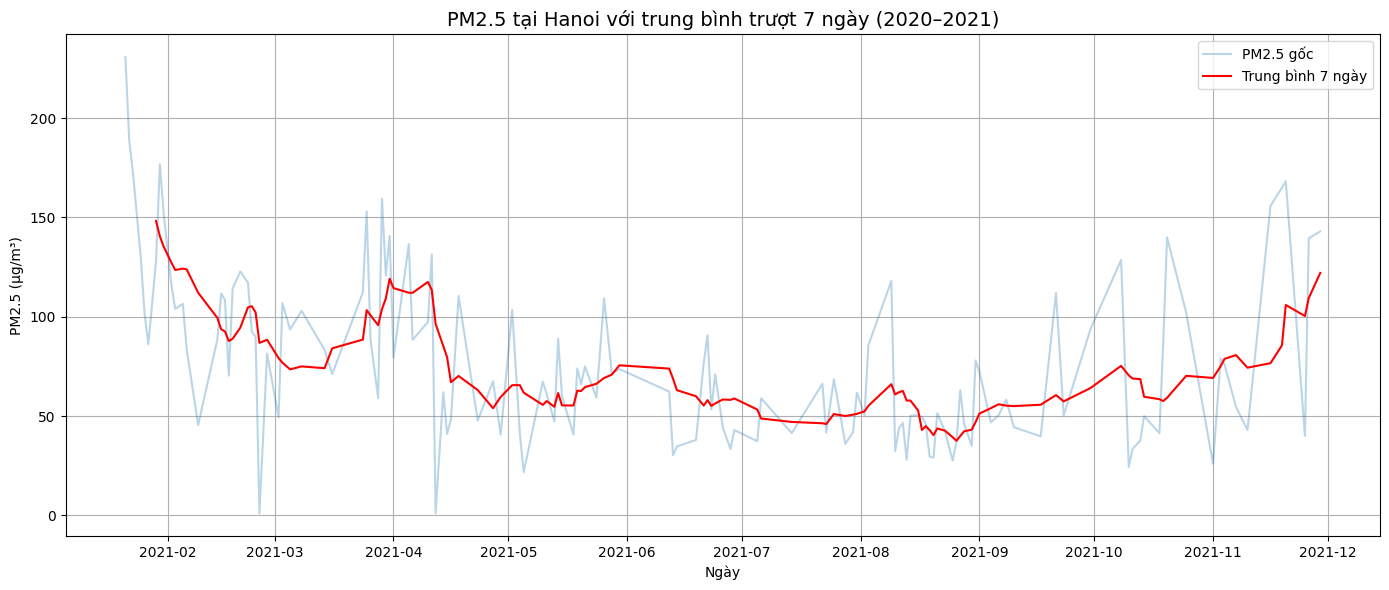

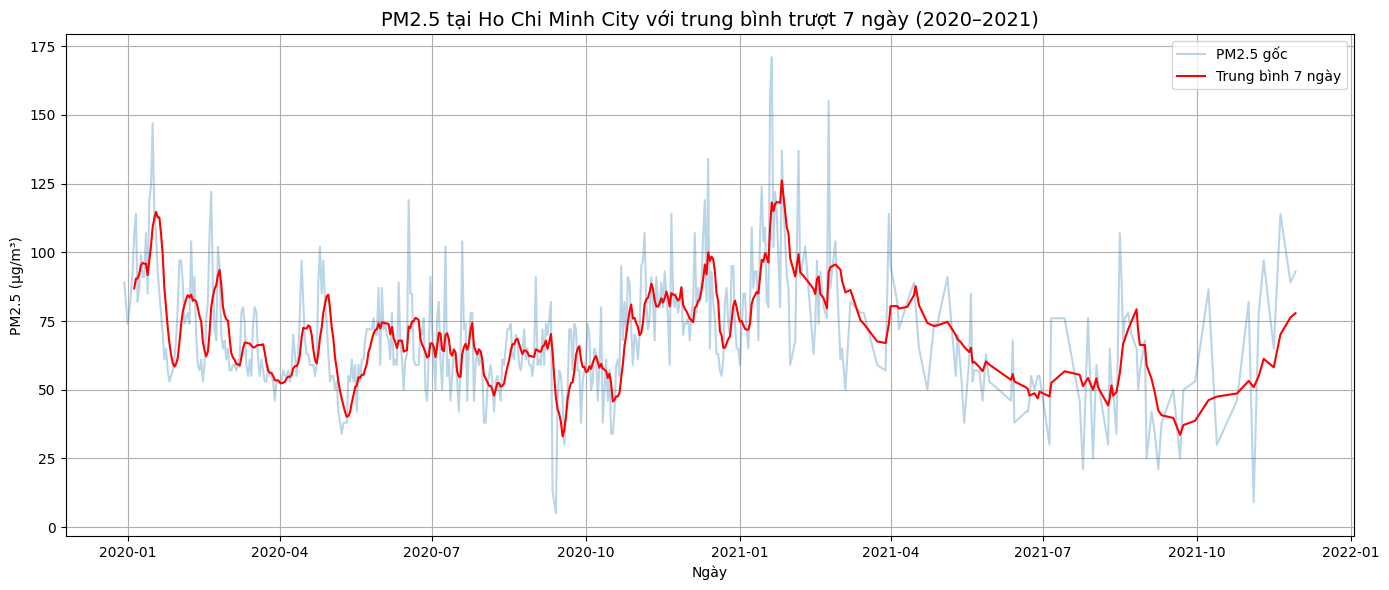

In [ ]:
import matplotlib.pyplot as plt

def plot_ma_city(city_name):
    df_city = df_all_pm25[df_all_pm25['City'] == city_name]
    df_city_daily = df_city.groupby('Date')['PM2.5'].mean().reset_index()
    df_city_daily['MA7'] = df_city_daily['PM2.5'].rolling(window=7).mean()
#vẽ biểu đồ
    plt.figure(figsize=(14,6))
    plt.plot(df_city_daily['Date'], df_city_daily['PM2.5'], label='PM2.5 gốc', alpha=0.3)
    plt.plot(df_city_daily['Date'], df_city_daily['MA7'], label='Trung bình 7 ngày', color='red')

    plt.title(f'PM2.5 tại {city_name} với trung bình trượt 7 ngày (2020–2021)', fontsize=14)
    plt.xlabel('Ngày')
    plt.ylabel('PM2.5 (µg/m³)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Vẽ cho cả 2 thành phố
plot_ma_city('Hanoi')
plot_ma_city('Ho Chi Minh City')

In [ ]:
!pip install prophet


In [ ]:
from prophet import Prophet

# Lấy dữ liệu Hà Nội
df_hanoi = df_all_pm25[df_all_pm25['City'] == 'Hanoi']
df_hanoi_daily = df_hanoi.groupby('Date')['PM2.5'].mean().reset_index()

# Đổi tên cột để dùng cho Prophet
df_hanoi_daily.columns = ['ds', 'y']

# Huấn luyện mô hình Prophet
model_hn = Prophet()
model_hn.fit(df_hanoi_daily)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcpkvighc/_1r7gygc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcpkvighc/v6squqnp.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=39970', 'data', 'file=/tmp/tmpcpkvighc/_1r7gygc.json', 'init=/tmp/tmpcpkvighc/v6squqnp.json', 'output', 'file=/tmp/tmpcpkvighc/prophet_modeld_zlebqj/prophet_model-20250713151825.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:18:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


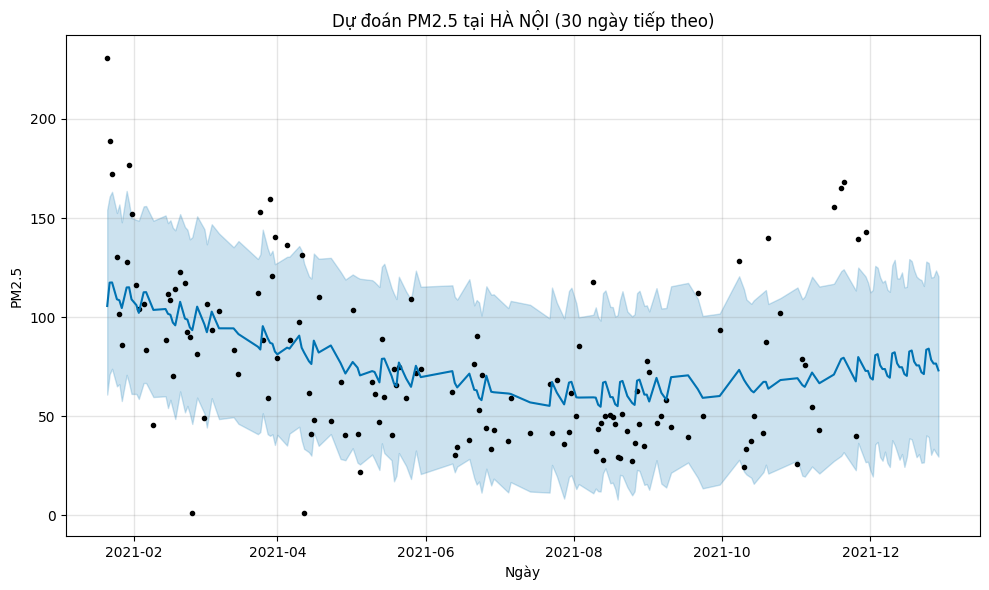

In [ ]:
#dự đoán 30 ngày tiếp theo của HN
future_hn = model_hn.make_future_dataframe(periods=30)
forecast_hn = model_hn.predict(future_hn)
fig = model_hn.plot(forecast_hn)
plt.title("Dự đoán PM2.5 tại HÀ NỘI (30 ngày tiếp theo)")
plt.xlabel("Ngày")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()



In [ ]:
# Lấy dữ liệu cho TP.HCM
df_hcm = df_all_pm25[df_all_pm25['City'] == 'Ho Chi Minh City']
df_hcm_daily = df_hcm.groupby('Date')['PM2.5'].mean().reset_index()

# Đổi tên cột cho Prophet
df_hcm_daily.columns = ['ds', 'y']
print(df_hcm_daily.head())


           ds     y
0  2019-12-30  89.0
1  2019-12-31  82.0
2  2020-01-01  74.0
3  2020-01-02  78.0
4  2020-01-03  85.0


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcpkvighc/qch6oi42.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpcpkvighc/agns02g9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=25680', 'data', 'file=/tmp/tmpcpkvighc/qch6oi42.json', 'init=/tmp/tmpcpkvighc/agns02g9.json', 'output', 'file=/tmp/tmpcpkvighc/prophet_modelx1awipzo/prophet_model-20250713153341.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:33:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:33:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


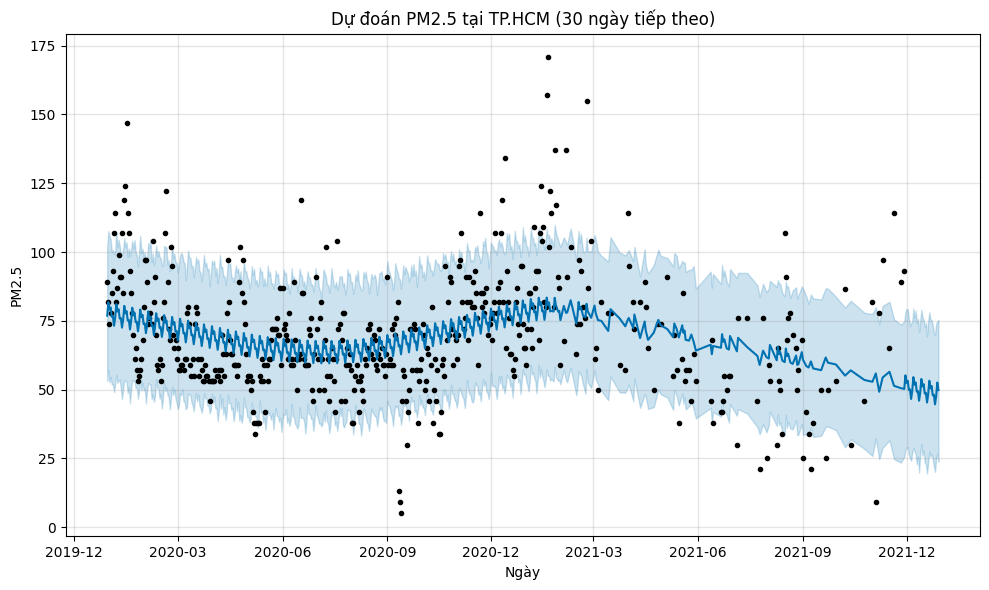

In [ ]:
# Huấn luyện mô hình Prophet cho TP.HCM
model_hcm = Prophet()
model_hcm.fit(df_hcm_daily)

# Dự đoán 30 ngày tiếp theo của TP.HCM
future_hcm = model_hcm.make_future_dataframe(periods=30)
forecast_hcm = model_hcm.predict(future_hcm)
fig = model_hcm.plot(forecast_hcm)
plt.title("Dự đoán PM2.5 tại TP.HCM (30 ngày tiếp theo)")
plt.xlabel("Ngày")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()
